# Basic correlations

In [223]:
import pandas as pd

def load_data(drop_columns=None):
    real_x_train = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_X_train.csv")
    random_x_train = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/random_X_train.csv")
    shuffle_x_train = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/shuffle_X_train.csv")

    real_x_val = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_X_val.csv")
    random_x_val = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/random_X_val.csv")
    shuffle_x_val = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/shuffle_X_val.csv")

    real_y_train = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_y_train.csv")
    real_y_val = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_y_val.csv")

    real_train = real_x_train.merge(real_y_train, on="complex_filename")
    real_train.set_index("complex_filename", inplace=True)
    real_train.drop(columns=["Unnamed: 0", "complex_filename.1"], inplace=True)
    if drop_columns:
        real_train.drop(columns=drop_columns, inplace=True)
    real_val = real_x_val.merge(real_y_val, on="complex_filename")
    real_train.head()
    return real_train, real_val, random_x_train, random_x_val, shuffle_x_train, shuffle_x_val

real_train, real_val, random_x_train, random_x_val, shuffle_x_train, shuffle_x_val = load_data()

In [224]:
real_train

,alphafold_iptm,alphafold_rosetta_score,alphafold_interface_sasa,alphafold_interface_dG,alphafold_interface_delta_hbond_unsat,alphafold_packstat,alphafold_distance_score,alphafold_n_contacts,alphafold_peptide_plddt,alphafold_interface_peptide_plddt,...,polar_aa_percent,positively_charged_aa_percent,negatively_charged_aa_percent,delta_net_charge_frac,uHrel,alphafold_ipsae_max,boltz_ipsae_max,alphafold_ipsae_min,boltz_ipsae_min,pKd
complex_filename,,,,,,,,,,,,,,,,,,,,,
4b4n_PVLFPGQPFGQPPLG,0.89,-292.878181,1111.515921,-42.460859,4,0.682295,6.420809,17,90.187333,80.162667,...,0.133333,0.000000,0.000000,0.000000,0.298596,0.778439,0.560533,0.324761,0.167745,3.441291
2o9v_VPPPVPPPPS,0.77,-174.809752,806.670547,-23.438914,1,0.637674,7.028242,12,89.143000,89.143000,...,0.100000,0.000000,0.000000,0.000000,0.477438,0.458830,0.900362,0.228499,0.824738,3.540608
2n9x_DYESDDDSYEVLDLTEY,0.58,-115.397252,1637.454050,-27.798335,10,0.558106,6.093058,20,51.976471,47.215882,...,0.176471,0.000000,0.470588,-0.470588,0.314894,0.408341,0.753203,0.122287,0.327123,6.397940
1eol_RDYEPIPEEAA,0.86,-415.296812,1125.923668,-30.520757,8,0.561574,6.688524,15,79.595455,72.408182,...,0.000000,0.090909,0.363636,-0.272727,0.440445,0.504507,0.528216,0.128515,0.061313,13.420216
2kgi_ARTQTARK,0.67,37.108617,972.603474,-31.027084,5,0.696622,5.507655,18,78.305000,78.305000,...,0.375000,0.375000,0.000000,0.375000,0.239220,0.322313,0.665786,0.200276,0.602039,6.124939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2oei_PPPPPPLPP,0.42,66.929219,704.135176,-18.637616,2,0.703193,6.782480,9,68.494444,62.285556,...,0.000000,0.000000,0.000000,0.000000,0.445618,0.075621,0.485546,0.072678,0.421767,3.906578
5z2w_NGGQEALEERARNELSMTRPGETFYRLVPDASKRA,0.89,-375.593320,1936.627841,-47.046971,2,0.619002,5.765663,23,88.307714,69.176857,...,0.200000,0.171429,0.171429,0.000000,0.371962,0.638706,0.364948,0.356416,0.035600,6.173925
5vko_GVPYSNESGLVNADLDVKDELMFPLVDSG,0.84,-448.177958,3313.363909,-89.654903,14,0.626382,6.352590,49,82.171034,79.630000,...,0.172414,0.034483,0.206897,-0.172414,0.127087,0.615580,0.013832,0.210657,0.012341,8.397940


<Axes: xlabel='None'>

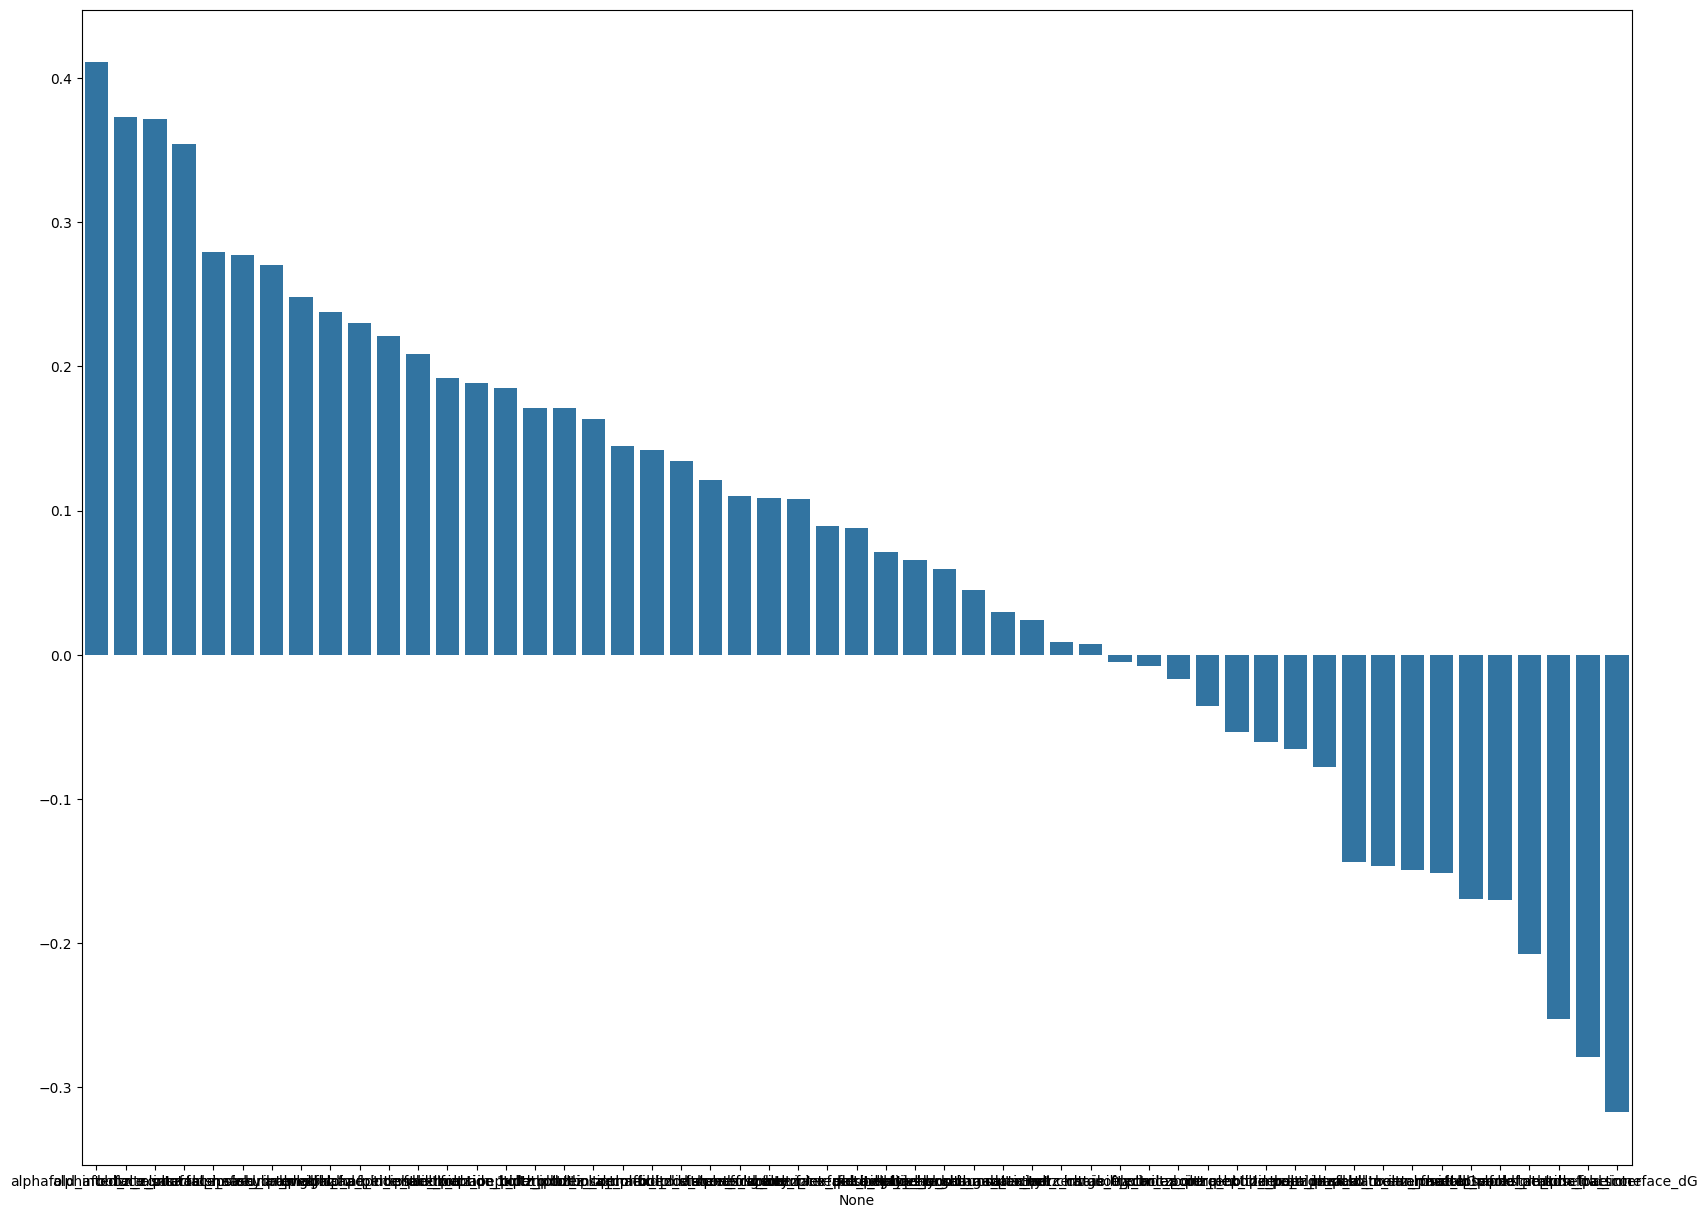

In [225]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

plt.figure(figsize=(20, 15))
df_corr = real_train.corr()
pKd_corr = df_corr["pKd"].sort_values(ascending=False)
pKd_corr = pKd_corr.drop(["pKd", "boltz_ligand_iptm", "boltz_complex_pde"])

sns.barplot(y=pKd_corr.values, x=pKd_corr.index)

# Regression fit

In [226]:
def load_regression_data():
    base_dirs = [
        "/home/er8813ha/immunopeptides/plots_v2_both/regression/",
        "/home/er8813ha/immunopeptides/plots_v2_boltz/regression/",
        "/home/er8813ha/immunopeptides/plots_v2_alphafold/regression/"
    ]
    train_regression_predictions = []
    val_regression_predictions = []
    regression_scaling_parameters = []
    symbolic_equations = []
    for base_dir in base_dirs:
        train_regression_predictions_temp = pd.read_csv(base_dir + "train_predictions.csv")
        val_regression_predictions_temp = pd.read_csv(base_dir + "val_predictions.csv")
        regression_scaling_parameters_temp = pd.read_csv(base_dir + "scaling_params.csv")
        symbolic_equations_temp = pd.read_csv(base_dir + "symbolic_regression_all_equations.csv")
        train_regression_predictions_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        val_regression_predictions_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        regression_scaling_parameters_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        symbolic_equations_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]

        train_regression_predictions.append(train_regression_predictions_temp)
        val_regression_predictions.append(val_regression_predictions_temp)
        regression_scaling_parameters.append(regression_scaling_parameters_temp)
        symbolic_equations.append(symbolic_equations_temp)

    train_regression_predictions = pd.concat(train_regression_predictions, ignore_index=True)
    val_regression_predictions = pd.concat(val_regression_predictions, ignore_index=True)
    regression_scaling_parameters = pd.concat(regression_scaling_parameters, ignore_index=True)
    symbolic_equations = pd.concat(symbolic_equations, ignore_index=True)

    return train_regression_predictions, val_regression_predictions, regression_scaling_parameters, symbolic_equations

train_regression_predictions, val_regression_predictions, regression_scaling_parameters, symbolic_equations = load_regression_data()
regression_scaling_parameters

,Unnamed: 0,mean,std,min,max,data_type
0,alphafold_iptm,0.760023,0.198000,0.040000,0.970000,both
1,alphafold_rosetta_score,-322.740349,297.181321,-1060.764822,845.380246,both
2,alphafold_interface_sasa,1520.322709,577.770405,523.658512,3407.262088,both
3,alphafold_interface_dG,-42.442036,29.234520,-117.400235,324.226461,both
4,alphafold_interface_delta_hbond_unsat,6.626126,5.199830,0.000000,31.000000,both
...,...,...,...,...,...,...
115,negatively_charged_aa_percent,0.123476,0.125664,0.000000,0.684211,alphafold
116,delta_net_charge_frac,0.053582,0.214254,-0.684211,0.750000,alphafold
117,uHrel,0.284400,0.155762,0.011677,0.766569,alphafold
118,alphafold_ipsae_max,0.532314,0.267605,0.000000,0.925535,alphafold


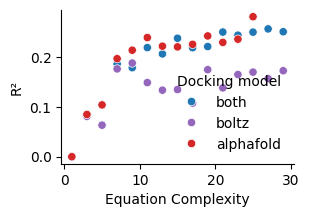

In [227]:
plt.figure(figsize=(3,2))
sns.scatterplot(symbolic_equations, x="complexity", y="val_r2",  hue="data_type", palette=["tab:blue", "tab:purple", "tab:red"])
plt.xlabel("Equation Complexity")
plt.ylabel("R²")
sns.despine()
plt.legend(title="Docking model", loc='lower right', frameon=False)
plt.savefig("./plots/v2_regression_equation_complexity_vs_val_r2.svg", dpi=300, bbox_inches='tight')

In [228]:
symbolic_equations.sort_values("val_r2", ascending=False)[["data_type", "complexity", "equation"]].values

array([['alphafold', 25,
        '1.9044503*alphafold_distance_score*(alphafold_interface_peptide_plddt + instability_index)*(alphafold_interface_sasa - alphafold_packstat + hydrophobic_aa_percent*(hydrophobic_aa_percent + uHrel)) + 1.9044503*alphafold_interface_sasa + alphafold_iptm + alphafold_packstat + 3.7507498'],
       ['both', 27,
        '1.51808385512659*boltz_chain_1_ptm*boltz_peptide_plddt*(alphafold_iptm + boltz_distance_score)*(boltz_interface_sasa - turn_fraction + (alphafold_iptm + intra_boltz_mean_rmsd)*(hydrophobic_aa_percent + intra_boltz_mean_rmsd)) + boltz_chain_1_ptm + 1.51808385512659*boltz_interface_sasa + 4.12975433122228'],
       ['both', 29,
        '1.44319511853683*boltz_chain_1_ptm*boltz_peptide_plddt*(alphafold_iptm + boltz_distance_score + intra_boltz_mean_rmsd)*(boltz_interface_sasa - turn_fraction + (alphafold_iptm + intra_boltz_mean_rmsd)*(hydrophobic_aa_percent + intra_boltz_mean_rmsd)) + boltz_chain_1_ptm + 1.44319511853683*boltz_interface_sasa + 4

In [229]:
regression_equation = '1.9044503*alphafold_distance_score*(alphafold_interface_peptide_plddt + instability_index)*(alphafold_interface_sasa - alphafold_packstat + hydrophobic_aa_percent*(hydrophobic_aa_percent + uHrel)) + 1.9044503*alphafold_interface_sasa + alphafold_iptm + alphafold_packstat + 3.7507498'#'1.38143251097807*boltz_chain_1_ptm + 1.38143251097807*boltz_interface_sasa + 1.38143251097807*boltz_peptide_plddt*(alphafold_iptm + boltz_distance_score)*(boltz_interface_sasa - turn_fraction + (alphafold_iptm + intra_boltz_mean_rmsd)*(hydrophobic_aa_percent + intra_boltz_mean_rmsd)) + 3.82578312545652'

In [230]:
def symbolic_predict(df, scaling_parameters, equation='3.6232204*boltz_chain_1_ptm - boltz_interface_dG + 3.6232204*boltz_interface_sasa + 2.24350459347672'):
    """ Scale using parameters and min-max then predict using symbolic equation """
    df = df.copy()
    for _, row in scaling_parameters.iterrows():
        feature = row['Unnamed: 0']
        min_val = row['min']
        max_val = row['max']
        df[feature] = (df[feature] - min_val) / (max_val - min_val)
    features = df.columns.tolist()
    symbolic_pred = eval(equation, {}, df.to_dict(orient='series'))
    return pd.DataFrame({'symbolic_pred': symbolic_pred, "complex_filename": df["complex_filename"]})

val_predictions = symbolic_predict(real_val, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "alphafold"], regression_equation)
val_predictions = val_predictions.merge(real_val[["complex_filename", "pKd"]], on="complex_filename")
val_predictions.head()

,symbolic_pred,complex_filename,pKd
0,6.673442,2khs_GSVAYVYKPNNTHEQLLRKSEAQAKKEKLNIWSED,6.443697
1,4.621916,2khh_DSGFSFGSK,6.559091
2,4.979249,2rnx_STGGVKPHRYKC,3.395774
3,5.158084,2vwf_IQPPPVNRNLKPDR,5.060481
4,5.747991,2lp8_GCVGRALAAFGDCINR,7.515700


Train R: 0.5344071542526216


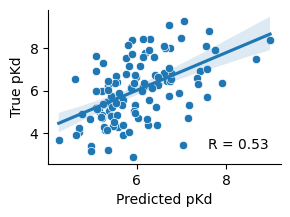

In [231]:

plt.figure(figsize=(3,2))
r = stats.pearsonr(val_predictions["symbolic_pred"], val_predictions["pKd"])[0]
print("Train R:", r)
sns.scatterplot(val_predictions, x="symbolic_pred", y="pKd", color="tab:blue", label=f'R = {r:.2f}')
sns.regplot(val_predictions, x="symbolic_pred", y="pKd", scatter=False, color="tab:blue")
plt.legend(frameon=False)
plt.xlabel("Predicted pKd")
plt.ylabel("True pKd")
sns.despine()
plt.savefig("./plots/v2_regression_equation_val_pred_vs_true.svg", dpi=300, bbox_inches='tight')

In [232]:
val_regression_predictions

,complex_filename,y_val,lasso_pred,rf_pred,svr_pred,symbolic_pred,data_type
0,2khs_GSVAYVYKPNNTHEQLLRKSEAQAKKEKLNIWSED,6.443697,6.292161,7.074821,5.705340,6.057033,both
1,2khh_DSGFSFGSK,6.559091,4.497381,4.889349,4.552785,4.482116,both
2,2rnx_STGGVKPHRYKC,3.395774,4.911731,5.207160,4.874541,5.192068,both
3,2vwf_IQPPPVNRNLKPDR,5.060481,5.443103,5.386268,5.270290,4.852495,both
4,2lp8_GCVGRALAAFGDCINR,7.515700,5.955539,5.641272,5.744029,6.166353,both
...,...,...,...,...,...,...,...
328,4poj_KHKILHRLLQD,8.096910,6.043737,6.806464,6.370130,6.600066,alphafold
329,3wdz_KEVDPTGELQ,6.920819,5.584955,5.018274,5.035117,5.092565,alphafold
330,4zsh_KHKILHRLLQD,7.045757,5.993640,6.553089,6.336409,6.717008,alphafold
331,5wuj_FSEEEVRYEIILEKIRGTLKERPDEIAMLFKLLIKDE,6.374688,7.451436,7.708483,7.713211,7.898575,alphafold


# Classification fit

In [233]:
def load_classification_data():
    base_dirs = [
        "/home/er8813ha/immunopeptides/plots_v2_both/classification/",
        "/home/er8813ha/immunopeptides/plots_v2_boltz/classification/",
        "/home/er8813ha/immunopeptides/plots_v2_alphafold/classification/"
    ]
    train_classification_predictions = []
    val_classification_predictions = []
    classification_scaling_parameters = []
    symbolic_equations = []
    for base_dir in base_dirs:
        train_classification_predictions_temp = pd.read_csv(base_dir + "train_predictions.csv")
        val_classification_predictions_temp = pd.read_csv(base_dir + "val_predictions.csv")
        classification_scaling_parameters_temp = pd.read_csv(base_dir + "scaling_params.csv")
        symbolic_equations_temp = pd.read_csv(base_dir + "symbolic_classification_all_equations.csv")
        train_classification_predictions_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        val_classification_predictions_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        classification_scaling_parameters_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]
        symbolic_equations_temp["data_type"] = base_dir.split("/")[-3].split("_v2_")[-1]

        train_classification_predictions.append(train_classification_predictions_temp)
        val_classification_predictions.append(val_classification_predictions_temp)
        classification_scaling_parameters.append(classification_scaling_parameters_temp)
        symbolic_equations.append(symbolic_equations_temp)

    train_classification_predictions = pd.concat(train_classification_predictions, ignore_index=True)
    val_classification_predictions = pd.concat(val_classification_predictions, ignore_index=True)
    classification_scaling_parameters = pd.concat(classification_scaling_parameters, ignore_index=True)
    symbolic_equations = pd.concat(symbolic_equations, ignore_index=True)

    return train_classification_predictions, val_classification_predictions, classification_scaling_parameters, symbolic_equations

train_classification_predictions, val_classification_predictions, classification_scaling_parameters, symbolic_equations = load_classification_data()

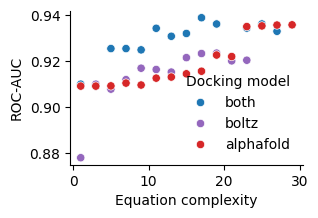

In [234]:
plt.figure(figsize=(3,2))
sns.scatterplot(symbolic_equations, x="complexity", y="val_auc", hue="data_type", palette=["tab:blue", "tab:purple", "tab:red"])
plt.xlabel("Equation complexity")
plt.ylabel("ROC-AUC")
plt.legend(title="Docking model", loc='lower right', frameon=False)
sns.despine()
plt.savefig("./plots/v2_classification_equation_complexity_vs_val_auc.svg", dpi=300, bbox_inches='tight')

In [235]:
symbolic_equations.sort_values("val_auc").tail(10)[["data_type", "complexity", "equation"]].values

array([['both', 27,
        '0.71949850272432*alphafold_ipsae_max + 0.4913392*boltz_peptide_plddt - gravy*positively_charged_aa_percent*(gravy + positively_charged_aa_percent + 1.4821618)*(boltz_chain_0_ptm - boltz_confidence_score - isoelectric_point + 1.0118821) + 0.080616548027488'],
       ['both', 11,
        '0.7035934558447*alphafold_ipsae_max + 0.5960651*boltz_peptide_plddt - 0.212465593407681*hydrophobic_aa_percent'],
       ['both', 23,
        '0.73903426507263*alphafold_ipsae_max + 0.5327563*boltz_peptide_plddt - 1.0655126*positively_charged_aa_percent*(gravy + hydrophobic_aa_percent)*(boltz_chain_0_ptm - boltz_confidence_score - isoelectric_point + 0.9003941)'],
       ['alphafold', 23,
        'alphafold_packstat*delta_net_charge_frac**2 + alphafold_peptide_plddt**2 - 1.1880411*negatively_charged_aa_percent*(0.91809845*inter_model_rmsd + 0.91809845*isoelectric_point + positively_charged_aa_percent - 0.52095366556846)'],
       ['alphafold', 25,
        'alphafold_packstat

In [236]:
classification_equation = '0.71949850272432*alphafold_ipsae_max + 0.4913392*boltz_peptide_plddt - gravy*positively_charged_aa_percent*(gravy + positively_charged_aa_percent + 1.4821618)*(boltz_chain_0_ptm - boltz_confidence_score - isoelectric_point + 1.0118821) + 0.080616548027488'

In [237]:
predictions_real = symbolic_predict(real_val, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
predictions_random = symbolic_predict(random_x_val, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
predictions_shuffle = symbolic_predict(shuffle_x_val, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)

predictions_random["type"] = "random"
predictions_shuffle["type"] = "shuffle"
predictions_real["type"] = "real"

all_predictions = pd.concat([predictions_real, predictions_random, predictions_shuffle])

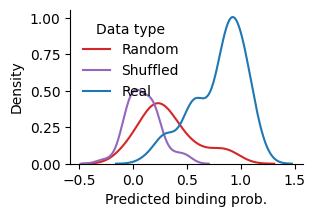

In [239]:
plt.figure(figsize=(3,2))
sns.kdeplot(all_predictions, x="symbolic_pred", hue="type", palette=["tab:blue", "tab:purple", "tab:red"])
plt.xlabel("Predicted binding prob.")
plt.legend( labels=["Random", "Shuffled", "Real"], title="Data type", loc='upper left', frameon=False)
sns.despine()
plt.savefig("./plots/v2_classification_equation_val_pred_distribution.svg", dpi=300, bbox_inches='tight')

# Test set combined

In [204]:
real_x_test = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_X_test.csv")
real_y_test = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/real_y_test.csv")
shuffle_x_test = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/shuffle_X_test.csv")
random_x_test = pd.read_csv("/home/er8813ha/immunopeptides/data/x_y_v2/random_X_test.csv")
real_test = real_x_test.merge(real_y_test, on="complex_filename")

Test R: 0.5203226781098886


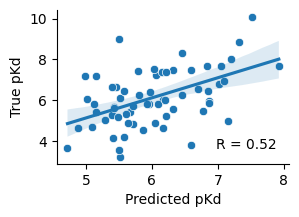

In [207]:
test_predictions_reg = symbolic_predict(real_test, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "alphafold"], regression_equation)
test_predictions_reg = test_predictions_reg.merge(real_test[["complex_filename", "pKd"]], on="complex_filename")
plt.figure(figsize=(3,2))
r = stats.pearsonr(test_predictions_reg["symbolic_pred"], test_predictions_reg["pKd"])[0]
print("Test R:", r)
sns.scatterplot(test_predictions_reg, x="symbolic_pred", y="pKd", color="tab:blue", label=f'R = {r:.2f}')
sns.regplot(test_predictions_reg, x="symbolic_pred", y="pKd", scatter=False, color="tab:blue")
sns.despine()
plt.legend(frameon=False)
plt.xlabel("Predicted pKd")
plt.ylabel("True pKd")
plt.savefig("./plots/v2_regression_equation_test_pred_vs_true.svg", dpi=300, bbox_inches='tight')

Test R: 0.2900833715620624


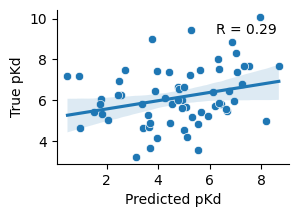

In [210]:
test_predictions_classification = symbolic_predict(real_test, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
test_predictions_real = test_predictions_classification.merge(test_predictions_reg, on="complex_filename", suffixes=("_classif", "_reg"))
test_predictions_real["total_pred"] = test_predictions_real["symbolic_pred_classif"] * test_predictions_real["symbolic_pred_reg"]
plt.figure(figsize=(3,2))
r2 = stats.pearsonr(test_predictions_real["total_pred"], test_predictions_real["pKd"])[0]
print("Test R:", r2)
sns.scatterplot(test_predictions_real, x="total_pred", y="pKd", color="tab:blue", label=f'R = {r2:.2f}')
sns.regplot(test_predictions_real, x="total_pred", y="pKd", scatter=False, color="tab:blue")
sns.despine()
plt.legend(frameon=False)
plt.xlabel("Predicted pKd")
plt.ylabel("True pKd")
plt.savefig("./plots/v2_combined_equation_test_pred_vs_true.svg", dpi=300, bbox_inches='tight')

In [211]:
random_predictions_class = symbolic_predict(random_x_test, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
shuffle_predictions_class = symbolic_predict(shuffle_x_test, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
random_predictions_reg = symbolic_predict(random_x_test, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "both"], regression_equation)
shuffle_predictions_reg = symbolic_predict(shuffle_x_test, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "both"], regression_equation)

random_predictions = random_predictions_class.merge(
    random_predictions_reg,
    on="complex_filename",
    suffixes=("_classif", "_reg")
)
shuffle_predictions = shuffle_predictions_class.merge(
    shuffle_predictions_reg,
    on="complex_filename",
    suffixes=("_classif", "_reg")
)
shuffle_predictions["total_pred"] = shuffle_predictions["symbolic_pred_classif"] * shuffle_predictions["symbolic_pred_reg"]
random_predictions["total_pred"] = random_predictions["symbolic_pred_classif"] * random_predictions["symbolic_pred_reg"]

all_predictions = pd.concat([
    test_predictions_real.assign(type="real"),
    random_predictions.assign(type="random"),
    shuffle_predictions.assign(type="shuffle"),
])
all_predictions.head()

,symbolic_pred_classif,complex_filename,symbolic_pred_reg,pKd,total_pred,type
0,1.101566,3h8k_WSADERQRMLVQRKDELLQQARKRFLNK,6.834361,7.677781,7.528502,real
1,0.670718,6fdp_DTSRMEEVD,5.397896,5.259637,3.620466,real
2,1.036731,3sri_KDIGAGPVASCFTTRMSPPQQICLN,7.017539,6.782516,7.275304,real
3,0.861334,2qbw_PQPVDSWV,6.065063,7.251812,5.224044,real
4,0.795295,2n2h_SNAAQLNYLLTDEQIMEDLRTLNKLKS,6.176764,6.031517,4.912351,real


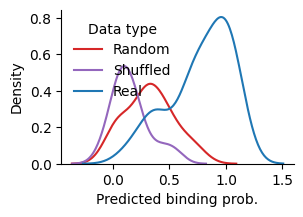

In [220]:
plt.figure(figsize=(3,2))
sns.kdeplot(all_predictions, x="symbolic_pred_classif", hue="type",  palette=["tab:blue", "tab:purple", "tab:red"])
plt.legend( labels=["Random", "Shuffled", "Real"], title="Data type", loc='upper left', frameon=False)
sns.despine()
plt.xlabel("Predicted binding prob.")
plt.savefig("./plots/v2_classification_equation_test_pred_distribution.svg", dpi=300, bbox_inches='tight')

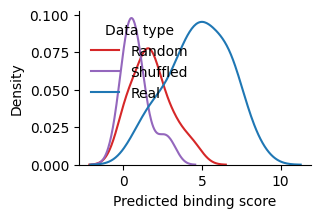

In [219]:
plt.figure(figsize=(3,2))
sns.kdeplot(all_predictions, x="total_pred", hue="type",  palette=["tab:blue", "tab:purple", "tab:red"])
plt.legend( labels=["Random", "Shuffled", "Real"], title="Data type", loc='upper left', frameon=False)
sns.despine()
plt.xlabel("Predicted binding score")
plt.savefig("./plots/v2_combined_equation_test_pred_distribution.svg", dpi=300, bbox_inches='tight')

# All data

Overall R2: 0.164836249023414


<Axes: xlabel='symbolic_pred_reg', ylabel='pKd'>

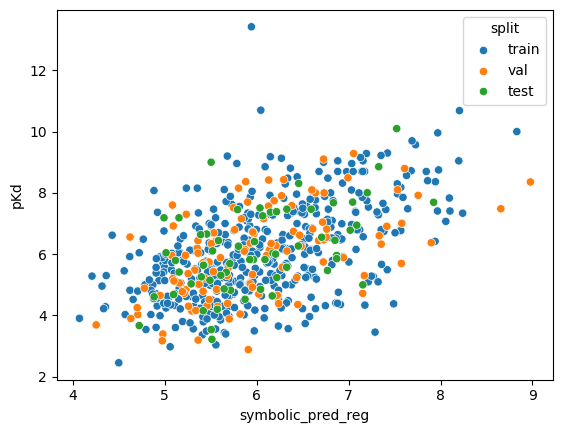

In [185]:
real_train_m = real_train.reset_index()
real_train_m["split"] = "train"
real_val["split"] = "val"
real_test["split"] = "test"
all_data = pd.concat([real_train_m, real_val, real_test])
all_pred_reg = symbolic_predict(all_data, regression_scaling_parameters[regression_scaling_parameters["data_type"] == "both"], regression_equation)
all_pred_class = symbolic_predict(all_data, classification_scaling_parameters[classification_scaling_parameters["data_type"] == "both"], classification_equation)
all_pred = all_pred_class.merge(all_pred_reg, on="complex_filename", suffixes=("_classif", "_reg"))
all_pred["symbolic_pred"] = all_pred["symbolic_pred_classif"] * all_pred["symbolic_pred_reg"]
all_pred = all_pred.merge(all_data[["complex_filename", "pKd", "split"]], on="complex_filename")


r2 = stats.pearsonr(all_pred["symbolic_pred"], all_pred["pKd"])[0]**2
print("Overall R2:", r2)
sns.scatterplot(all_pred, x="symbolic_pred_reg", y="pKd", hue="split")

# Importance

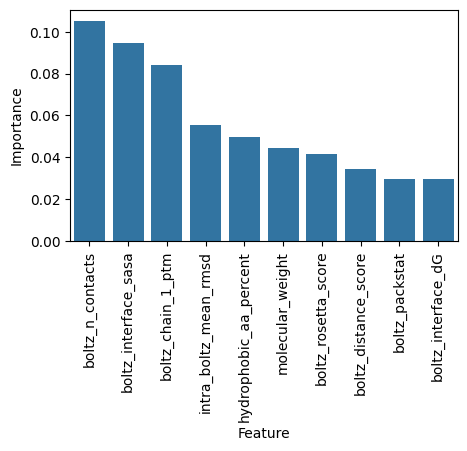

In [186]:
both_regression_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_both/regression/rf_feature_importance.csv")
alphafold_regression_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_alphafold/regression/rf_feature_importance.csv")
boltz_regression_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_boltz/regression/rf_feature_importance.csv")

both_classification_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_both/classification/rf_feature_importance.csv")
alphafold_classification_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_alphafold/classification/rf_feature_importance.csv")
boltz_classification_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v2_boltz/classification/rf_feature_importance.csv")

plt.figure(figsize=(5,3))
sns.barplot(data=boltz_regression_importance.head(10), x="Feature", y="Importance")
plt.xticks(rotation=90)
plt.show()

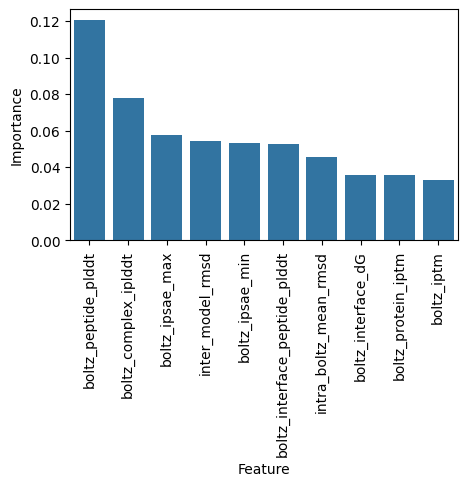

In [187]:
plt.figure(figsize=(5,3))
sns.barplot(data=boltz_classification_importance.head(10), x="Feature", y="Importance")
plt.xticks(rotation=90)
plt.show()